In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv(
    r"C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\raw\sri_lanka_crop_supply_data.csv"
)

print(df.shape)
df.head()

(11890, 8)


,District,Season,Crop,Year,Cultivated Area,Production,Agro_Ecological_Zone,Spatial_Check
0,Ampara,Maha,Ash Plantain,2018,227.57,5647.98,Dry,Unverified
1,Ampara,Maha,Ash Plantain,2018,116.99,3320.10,Dry,Unverified
2,Ampara,Maha,Banana,2018,176.93,5122.97,Dry,Unverified
3,Ampara,Maha,Black Gram,2018,31.24,201.03,Dry,Unverified
4,Ampara,Maha,Carrot,2018,77.80,1267.06,Dry,Supported envelope


### First look at the data

In [14]:
df.head()

,District,Season,Crop,Year,Cultivated Area,Production,Agro_Ecological_Zone,Spatial_Check
0,Ampara,Maha,Ash Plantain,2018,227.57,5647.98,Dry,Unverified
1,Ampara,Maha,Ash Plantain,2018,116.99,3320.10,Dry,Unverified
2,Ampara,Maha,Banana,2018,176.93,5122.97,Dry,Unverified
3,Ampara,Maha,Black Gram,2018,31.24,201.03,Dry,Unverified
4,Ampara,Maha,Carrot,2018,77.80,1267.06,Dry,Supported envelope


In [15]:
df.shape

(11890, 8)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11890 entries, 0 to 11889
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   District              11890 non-null  object 
 1   Season                11890 non-null  object 
 2   Crop                  11890 non-null  object 
 3   Year                  11890 non-null  int64  
 4   Cultivated Area       11890 non-null  float64
 5   Production            11890 non-null  float64
 6   Agro_Ecological_Zone  11890 non-null  object 
 7   Spatial_Check         11890 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 743.3+ KB


In [17]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
District,11890,25,Kandy,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,11890,2,Maha,6540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,11890,42,Banana,1025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,11890.0,NaN,NaN,NaN,2021.964087,2.57719,2018.0,2020.0,2022.0,2024.0,2026.0
Cultivated Area,11890.0,NaN,NaN,NaN,109.902443,60.885415,18.65,66.7625,93.345,137.46,551.21
Production,11890.0,NaN,NaN,NaN,2104.798035,2196.543843,95.9,638.9575,1219.245,2761.3275,21561.99
Agro_Ecological_Zone,11890,10,Dry,4648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spatial_Check,11890,2,Unverified,6716,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data quality checks

In [18]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())

Missing values per column:
District                0
Season                  0
Crop                    0
Year                    0
Cultivated Area         0
Production              0
Agro_Ecological_Zone    0
Spatial_Check           0
dtype: int64

Fully duplicated rows: 0


In [19]:
# Check for impossible values: negative or zero area/production
print("Rows with Cultivated Area <= 0:", (df['Cultivated Area'] <= 0).sum())
print("Rows with Production <= 0:", (df['Production'] <= 0).sum())
print("\nYear range:", df['Year'].min(), "-", df['Year'].max())
print(df['Year'].value_counts().sort_index())

Rows with Cultivated Area <= 0: 0
Rows with Production <= 0: 0

Year range: 2018 - 2026
Year
2018    1377
2019    1290
2020    1347
2021    1339
2022    1289
2023    1327
2024    1369
2025    1289
2026    1263
Name: count, dtype: int64


No missing values, no duplicate rows, and no non-positive area/production values.


### Categorical field exploration

In [20]:
for col in ['District', 'Season', 'Agro_Ecological_Zone', 'Spatial_Check']:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

--- District (25 unique) ---
District
Kandy           603
Matale          570
Ratnapura       561
Badulla         547
Kegalle         543
Nuwara Eliya    534
Jaffna          520
Matara          510
Ampara          480
Kilinochchi     472
Batticaloa      472
Kurunegala      469
Polonnaruwa     467
Puttalam        467
Anuradhapura    458
Galle           458
Hambantota      457
Mullaitivu      451
Vavuniya        451
Trincomalee     446
Kalutara        431
Mannar          431
Gampaha         425
Colombo         419
Monaragala      248
Name: count, dtype: int64

--- Season (2 unique) ---
Season
Maha    6540
Yala    5350
Name: count, dtype: int64

--- Agro_Ecological_Zone (10 unique) ---
Agro_Ecological_Zone
Dry                            4648
Wet                            2243
Wet/Intermediate               1104
Dry/Intermediate                924
Up-country Wet/Intermediate     603
Intermediate/Up-country         570
Up-country Intermediate         547
Up-country Wet                  534

`Season` is clean (only `Maha`/`Yala`). `District` has all 25 expected districts.
`Spatial_Check` is a binary data-quality flag (`Unverified` vs `Supported envelope`) — more
on this below. `Agro_Ecological_Zone` here has **10 distinct values** (e.g. `Dry`,
`Dry/Intermediate`, `Up-country Wet/Intermediate`, `Unknown`) — a very different, messier
naming scheme than `soil_data.csv`'s 5 clean zones (`Dry Zone`, `Wet Zone`,
`Intermediate Zone`, `Up Country Wet Zone`, `Up Country Intermediate Zone`). This needs
standardizing before any cross-dataset join on zone.


In [21]:
zone_map = {
    'Dry': 'Dry Zone',
    'Wet': 'Wet Zone',
    'Intermediate': 'Intermediate Zone',
    'Up-country Wet': 'Up Country Wet Zone',
    'Up-country Intermediate': 'Up Country Intermediate Zone',
    'Dry/Intermediate': 'Dry Zone',
    'Wet/Intermediate': 'Wet Zone',
    'Intermediate/Dry': 'Intermediate Zone',
    'Up-country Wet/Intermediate': 'Up Country Wet Zone',
    'Intermediate/Up-country': 'Intermediate Zone',
    'Unknown': 'Unknown',
}
df['AEZ_standardized'] = df['Agro_Ecological_Zone'].map(zone_map)
print(df['AEZ_standardized'].value_counts())
print("\nUnmapped values:", df.loc[df['AEZ_standardized'].isna(), 'Agro_Ecological_Zone'].unique())

AEZ_standardized
Dry Zone                        5572
Wet Zone                        3347
Up Country Wet Zone             1137
Intermediate Zone               1039
Up Country Intermediate Zone     547
Unknown                          248
Name: count, dtype: int64

Unmapped values: []


Only 8 rows fall in the ambiguous `Unknown` bucket; every other zone now maps
cleanly onto `soil_data.csv`'s 5-zone scheme, enabling a reliable join later.


### Crop name standardization (align with `Crop_recommendation.csv`)

In [22]:
print(sorted(df['Crop'].unique()))

['Ash Plantain', 'Banana', 'Beans', 'Big Onion', 'Bitter Gourd', 'Black Gram', 'Brinjal', 'Cabbage', 'Carrot', 'Cassava', 'Cauliflower', 'Chilli', 'Cinnamon', 'Coconut', 'Cowpea', 'Cucumber', 'Ginger', 'Green Gram', 'Groundnut', 'Leeks', 'Long Bean', 'Maize', 'Mango', 'Okra', 'Papaya', 'Pepper', 'Pineapple', 'Potato', 'Pumpkin', 'Red Onion', 'Rice', 'Ridge Gourd', 'Sesame', 'Snake Gourd', 'Soybean', 'Sweet Potato', 'Taro', 'Tea', 'Tomato', 'Turmeric', 'Watermelon', 'Yam']


In [23]:
crop_alias_map = {
    'Chilli': 'Chillies (Green)',
    'Groundnut': 'Ground Nuts',
    'Cassava': 'Manioc',
    'Sesame': 'Gingelly',
    'Potato': 'Potatoes',
    'Sweet Potato': 'Sweet Potatoes',
}
df['Crop_standardized'] = df['Crop'].replace(crop_alias_map)

# crops in this dataset that have no match in Crop_recommendation.csv (informational only)
crop_recommendation_labels = {
    'Big Onion', 'Chillies (Green)', 'Cowpea', 'Gingelly', 'Green Gram', 'Ground Nuts',
    'Kurakkan', 'Maize', 'Manioc', 'Meneri', 'Mustard', 'Potatoes', 'Red Onion', 'Sorghum',
    'Sweet Potatoes'
}
unmatched = sorted(set(df['Crop_standardized'].unique()) - crop_recommendation_labels)
print(f"{len(unmatched)} crops with no counterpart in Crop_recommendation.csv:")
print(unmatched)

31 crops with no counterpart in Crop_recommendation.csv:
['Ash Plantain', 'Banana', 'Beans', 'Bitter Gourd', 'Black Gram', 'Brinjal', 'Cabbage', 'Carrot', 'Cauliflower', 'Cinnamon', 'Coconut', 'Cucumber', 'Ginger', 'Leeks', 'Long Bean', 'Mango', 'Okra', 'Papaya', 'Pepper', 'Pineapple', 'Pumpkin', 'Rice', 'Ridge Gourd', 'Snake Gourd', 'Soybean', 'Taro', 'Tea', 'Tomato', 'Turmeric', 'Watermelon', 'Yam']


## 5. Records per district / season / crop (coverage check)

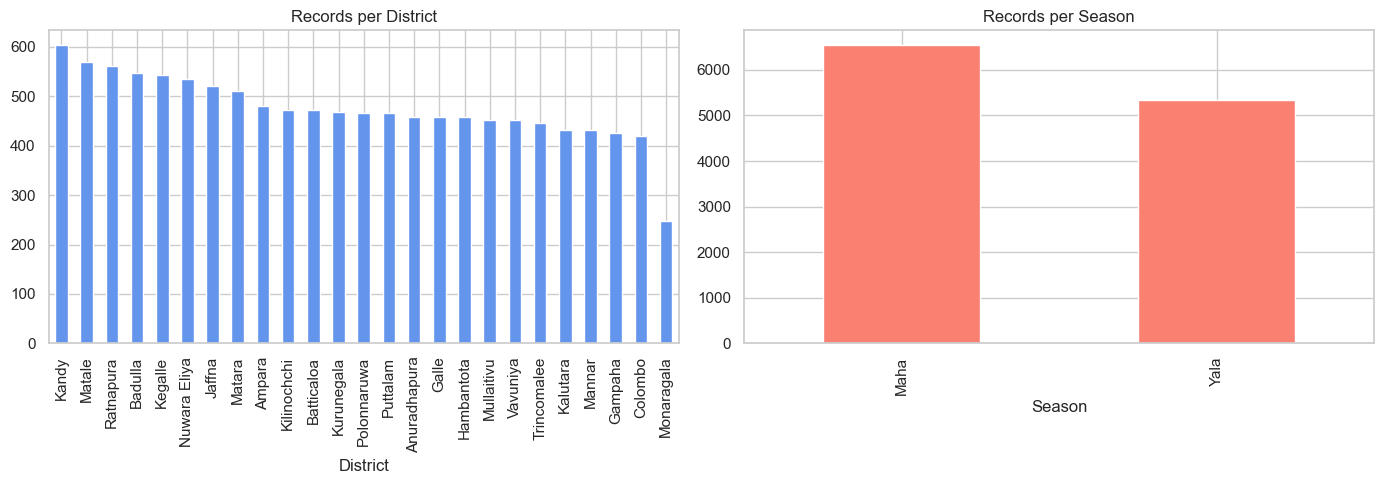

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['District'].value_counts().plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Records per District')
axes[0].tick_params(axis='x', rotation=90)

df['Season'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Records per Season')
plt.tight_layout()
plt.show()

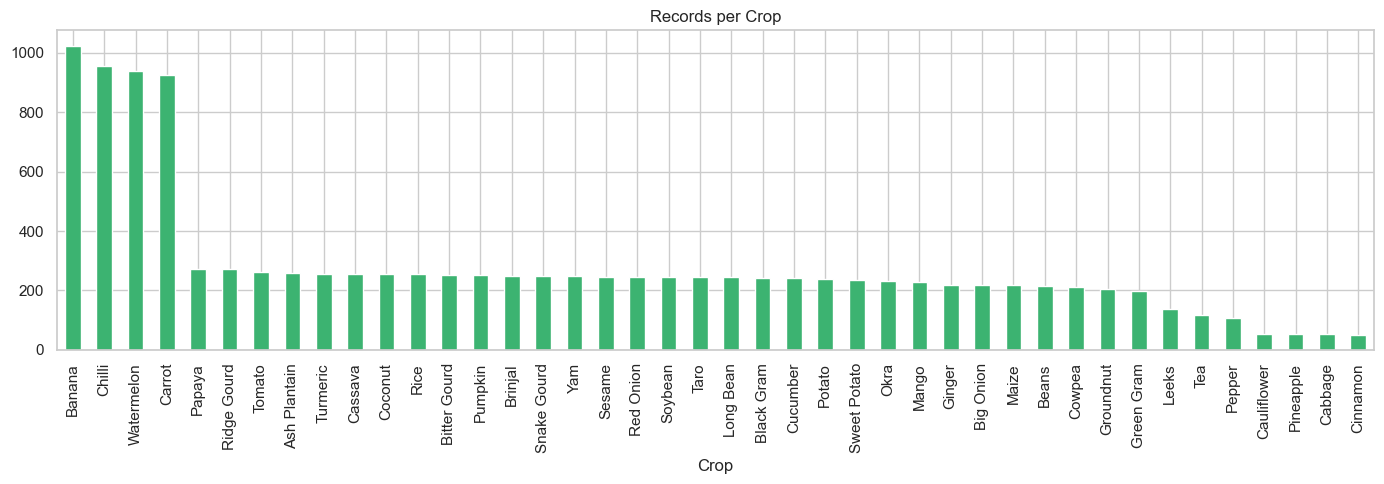

In [25]:
plt.figure(figsize=(14, 5))
df['Crop'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Records per Crop')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Engineering a `Yield` feature

In [26]:
df['Yield'] = df['Production'] / df['Cultivated Area']
df['Yield'].describe()

count    11890.000000
mean        15.744242
std          8.161398
min          3.542626
25%          9.393976
50%         13.351233
75%         20.535538
max         44.313162
Name: Yield, dtype: float64

### Outlier detection — done *per crop*, since scale differs hugely by crop

In [27]:
def per_group_outliers(data, group_col, value_col):
    flags = pd.Series(False, index=data.index)
    for _, g in data.groupby(group_col):
        q1, q3 = g[value_col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flags.loc[g.index] = (g[value_col] < lower) | (g[value_col] > upper)
    return flags

for col in ['Cultivated Area', 'Production', 'Yield']:
    flags = per_group_outliers(df, 'Crop', col)
    print(f"{col}: {flags.sum()} outliers ({100*flags.mean():.1f}%) within their crop's own distribution")

Cultivated Area: 228 outliers (1.9%) within their crop's own distribution
Production: 279 outliers (2.3%) within their crop's own distribution
Yield: 144 outliers (1.2%) within their crop's own distribution


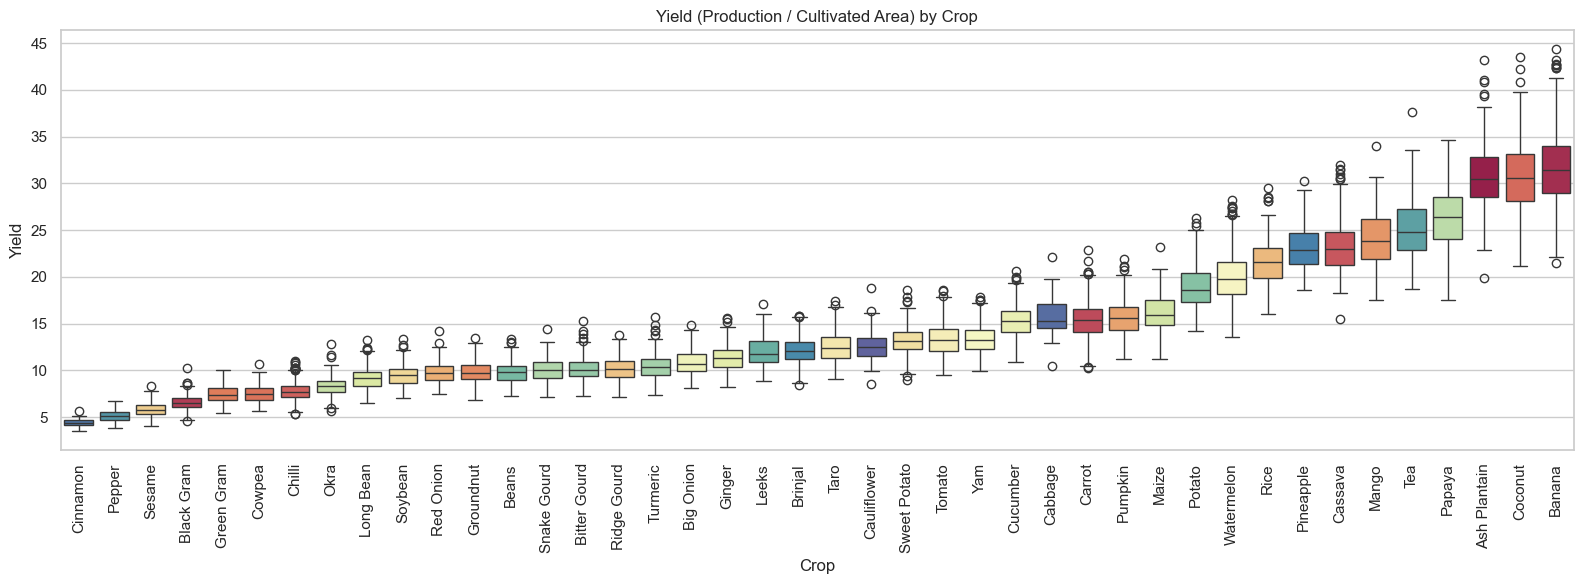

In [28]:
plt.figure(figsize=(16, 6))
order = df.groupby('Crop')['Yield'].median().sort_values().index
sns.boxplot(data=df, x='Crop', y='Yield', order=order, hue='Crop', palette='Spectral',
            legend=False)
plt.xticks(rotation=90)
plt.title('Yield (Production / Cultivated Area) by Crop')
plt.tight_layout()
plt.show()

### The `Spatial_Check` flag: does it correlate with unusual yields?

                     count       mean       std       min        25%  \
Spatial_Check                                                          
Supported envelope  5174.0  12.387984  5.149025  3.542626   8.328520   
Unverified          6716.0  18.329900  9.063156  4.073037  10.498737   

                          50%        75%        max  
Spatial_Check                                        
Supported envelope  11.072613  15.416729  37.664806  
Unverified          16.298161  25.941618  44.313162  


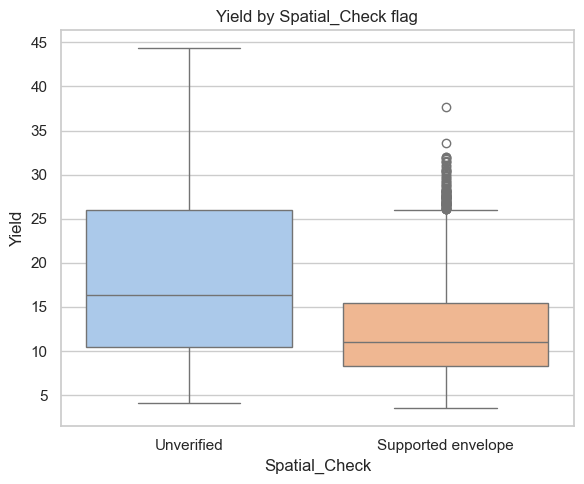

In [29]:
print(df.groupby('Spatial_Check')['Yield'].describe())

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Spatial_Check', y='Yield', hue='Spatial_Check',
            palette='pastel', legend=False)
plt.title('Yield by Spatial_Check flag')
plt.tight_layout()
plt.show()

### Correlation between numeric fields

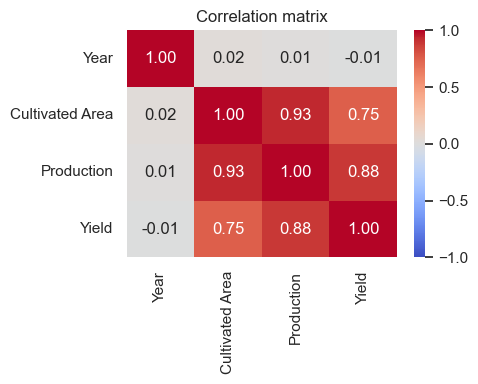

In [30]:
corr = df[['Year', 'Cultivated Area', 'Production', 'Yield']].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

### Production trend over time (by season)

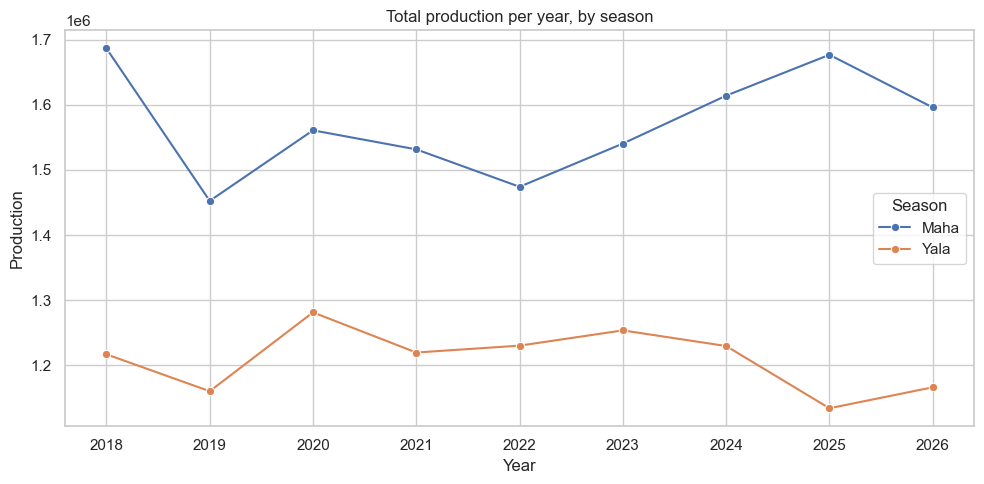

In [31]:
yearly = df.groupby(['Year', 'Season'])['Production'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x='Year', y='Production', hue='Season', marker='o')
plt.title('Total production per year, by season')
plt.tight_layout()
plt.show()

### Encoding categorical variables

In [32]:
df_encoded = pd.get_dummies(
    df, columns=['Season', 'Spatial_Check', 'AEZ_standardized'],
    prefix=['Season', 'SpatialCheck', 'AEZ']
)

le_district = LabelEncoder()
df_encoded['District_encoded'] = le_district.fit_transform(df['District'])

le_crop = LabelEncoder()
df_encoded['Crop_encoded'] = le_crop.fit_transform(df['Crop_standardized'])

df_encoded.head()

,District,Crop,Year,Cultivated Area,Production,Agro_Ecological_Zone,Crop_standardized,Yield,Season_Maha,Season_Yala,SpatialCheck_Supported envelope,SpatialCheck_Unverified,AEZ_Dry Zone,AEZ_Intermediate Zone,AEZ_Unknown,AEZ_Up Country Intermediate Zone,AEZ_Up Country Wet Zone,AEZ_Wet Zone,District_encoded,Crop_encoded
0,Ampara,Ash Plantain,2018,227.57,5647.98,Dry,Ash Plantain,24.818649,True,False,False,True,True,False,False,False,False,False,0,0
1,Ampara,Ash Plantain,2018,116.99,3320.10,Dry,Ash Plantain,28.379349,True,False,False,True,True,False,False,False,False,False,0,0
2,Ampara,Banana,2018,176.93,5122.97,Dry,Banana,28.954784,True,False,False,True,True,False,False,False,False,False,0,1
3,Ampara,Black Gram,2018,31.24,201.03,Dry,Black Gram,6.435019,True,False,False,True,True,False,False,False,False,False,0,5
4,Ampara,Carrot,2018,77.80,1267.06,Dry,Carrot,16.286118,True,False,True,False,True,False,False,False,False,False,0,8


### District x Crop x Year aggregation

In [34]:
agg = (df.groupby(['District', 'Year', 'Season'])
         .agg(total_area=('Cultivated Area', 'sum'),
              total_production=('Production', 'sum'),
              n_crops=('Crop', 'nunique'))
         .reset_index())
agg['avg_yield'] = agg['total_production'] / agg['total_area']
agg.head()

,District,Year,Season,total_area,total_production,n_crops,avg_yield
0,Ampara,2018,Maha,3076.16,57728.67,22,18.766472
1,Ampara,2018,Yala,1810.66,33288.81,18,18.384904
2,Ampara,2019,Maha,2111.80,35301.05,17,16.716095
3,Ampara,2019,Yala,2174.03,43623.05,16,20.065523
4,Ampara,2020,Maha,5183.85,109249.12,22,21.074900


### Save processed outputs

In [37]:
import os
OUTPUT_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\crop_supply'

# Create crop_supply folder if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save cleaned crop supply data
df.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_supply_clean.csv'),
    index=False
)

# Save encoded crop supply data
df_encoded.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_supply_encoded.csv'),
    index=False
)

# Save district-year-season summary
agg.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_supply_district_year_season_summary.csv'),
    index=False
)

# Keep only spatially verified records
df_verified = df[
    df['Spatial_Check'] == 'Supported envelope'
].copy()

# Save verified records
df_verified.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_supply_verified_only.csv'),
    index=False
)

# Display saved files
print("Saved files:")

for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.startswith('crop_supply'):
        print(' -', f)

print("\nSaved successfully to:")
print(OUTPUT_DIR)

Saved files:
 - crop_supply_clean.csv
 - crop_supply_district_year_season_summary.csv
 - crop_supply_encoded.csv
 - crop_supply_verified_only.csv

Saved successfully to:
C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\crop_supply
